In [1]:
import pandas as pd 
import numpy as np

In [2]:
# Read data
df = pd.read_csv("powerplant_data.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [3]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [4]:
df.info()
# AT --> Temperature
# V ---> Vaccum
# AP --> Pressure
# RH --> Humidity
# PE --> Produced energy

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [5]:
# split features
X = df.drop(["PE"] , axis=1)
y = df["PE"]

In [6]:
# Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X , y , test_size=0.2 , random_state=42
) 

In [7]:
# Data Scaling 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
import torch 
import torch.nn as nn

In [9]:
# Convering data to Tensors
X_train_tensor = torch.tensor(X_train_scaled ,dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values , dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled , dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values , dtype=torch.float32).view(-1,1)

In [10]:
X_train_tensor

tensor([[ 0.7481,  0.7201, -0.3266, -0.4971],
        [ 0.8618,  1.2652, -0.9852,  0.8182],
        [ 0.9341,  1.5231,  0.3252,  0.8017],
        ...,
        [-0.2210, -0.8350,  0.3676, -0.8355],
        [ 0.9475,  1.1425, -0.4197, -0.4546],
        [-1.7736, -1.1905,  1.9252,  0.9184]])

In [11]:
from torch.utils.data import DataLoader , TensorDataset

train_dataset = TensorDataset(X_train_tensor , y_train_tensor)
test_dataset = TensorDataset(X_test_tensor , y_test_tensor)

In [12]:
# DataLoader
train_loader = DataLoader(train_dataset , batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset , batch_size=32)

### Deep Learning

In [13]:
# ANN architechture 
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model = nn.Sequential(
            # 1st Hidden layer
            nn.Linear(X_train.shape[1],6),
    
            # 2nd Hidden layer
            nn.Linear(6,6),
            nn.ReLU(),
    
            # output layer
            nn.Linear(6,1),       
        )
    
    def forward(self,x):
        return self.model(x)

In [14]:
import torch.optim as optim

model = ANN()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [15]:
# Training ANN model
epochs = 100
training_loss = []
eval_loss = []

for epoch in range (epochs):
    model.train()
    running_train_loss = 0.0
    running_val_loss = 0.0

    for xbatch , ybatch in train_loader:
        # Xbatch ==> featues of 1batch
        # Ybatch ==> labels of 1batch
        optimizer.zero_grad()        # Set gradient to zero
        
        output = model(xbatch)       # forward prop.......predict output for 1batch   
        loss = criterion(output , ybatch)  # Compute loss
        loss.backward()              # backward prop......compute gradient 
        optimizer.step()             # Update params 

        running_train_loss += loss.item()         # Loss is tensor ==> py float

    epoch_train_loss = running_train_loss / len(train_loader)     # 1 epoch loss
    training_loss.append(epoch_train_loss)
    
    # Evaluation loss
    with torch.no_grad():           # No gradient calculated
        for xbatch , ybatch in test_loader:
    
            model.eval()
            output = model(xbatch)
            loss = criterion(output , ybatch)
            running_val_loss += loss.item()             # Keeping in tenor for understanding

    epoch_eval_loss = running_val_loss / len(test_loader)
    eval_loss.append(epoch_eval_loss)

    print(f"epoch {epoch+1}/{epochs} ==> Training Loss : {epoch_train_loss} , Testing Loss : {epoch_eval_loss}")
    

epoch 1/100 ==> Training Loss : 205667.109375 , Testing Loss : 203625.74739583334
epoch 2/100 ==> Training Loss : 196710.811328125 , Testing Loss : 185938.40130208334
epoch 3/100 ==> Training Loss : 168173.69772135417 , Testing Loss : 148973.14348958334
epoch 4/100 ==> Training Loss : 130695.13619791667 , Testing Loss : 117104.176171875
epoch 5/100 ==> Training Loss : 109382.89147135416 , Testing Loss : 105471.16653645833
epoch 6/100 ==> Training Loss : 102219.71598307292 , Testing Loss : 100245.32200520833
epoch 7/100 ==> Training Loss : 96426.28901367188 , Testing Loss : 93403.70716145834
epoch 8/100 ==> Training Loss : 87664.80935872396 , Testing Loss : 81137.34694010417
epoch 9/100 ==> Training Loss : 68521.20862630209 , Testing Loss : 52008.1072265625
epoch 10/100 ==> Training Loss : 27042.909635416665 , Testing Loss : 9621.32744140625
epoch 11/100 ==> Training Loss : 3887.4308590571086 , Testing Loss : 1366.1890940348308
epoch 12/100 ==> Training Loss : 726.4152190526327 , Testin

In [16]:
loss_df = pd.DataFrame({
    "Training loss" : training_loss,
    "Eval loss" : eval_loss
})

In [18]:
loss_df.head()

,Training loss,Eval loss
0,205667.109375,203625.747396
1,196710.811328,185938.401302
2,168173.697721,148973.143490
3,130695.136198,117104.176172
4,109382.891471,105471.166536


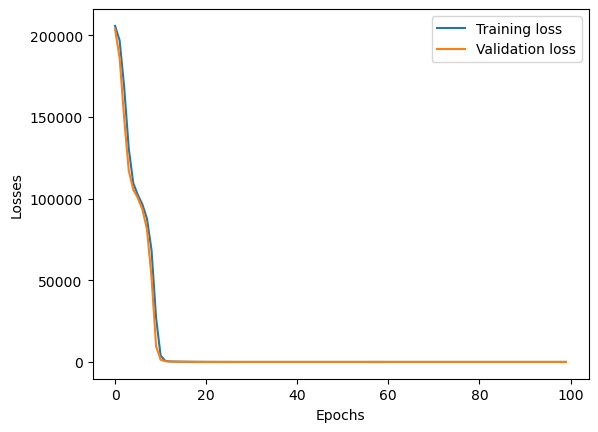

In [19]:
import matplotlib.pyplot as plt

# plt.figure(figsize=(12,8))

plt.plot(loss_df["Training loss"] , label="Training loss")
plt.plot(loss_df["Eval loss"] , label="Validation loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()